<a href="https://colab.research.google.com/github/sayu0303/CONTROLE-2025/blob/main/CONTROLE_280126_P5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CONTROLE - PRÁTICA 5 (IDENTIFICAÇÃO DE SISTEMAS)


###EXEMPLO RESOLVIDO

In [170]:
'''

BLOCO PARA INSTALAÇÃO DA BIBLIOTECA CONTROL

'''

#Instalção da biblioteca control

!pip install control -qq control

In [171]:
'''

BLOCO PARA IMPORTAÇÃO DAS BIBLIOTECAS

'''

#Importação das bibliotecas utilizadas

import numpy as np              #Biblioteca de operações matemáticas
import matplotlib.pyplot as plt #Biblioteca para plotar gráficos
import control as ct            #Biblioteca para implementação de controle

Text(0.5, 1.0, 'Temperatura em função do tempo')

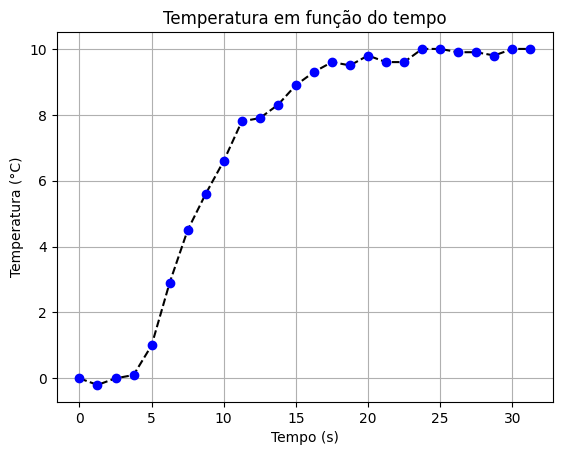

In [172]:
'''

BLOCO PARA IMPORTAÇÃO DOS DADOS EXPERIMENTAIS E
PLOTAGEM DOS GRÁFICOS

'''

#Definição dos dados de tempo e temperatura, propostas no exercício

t = np.array([ 0.  ,  1.25,  2.5 ,  3.75,  5.  ,  6.25,  7.5 ,  8.75, 10.,
       11.25, 12.5 , 13.75, 15.  , 16.25, 17.5 , 18.75, 20.  , 21.25,
       22.5 , 23.75, 25.  , 26.25, 27.5 , 28.75, 30., 31.25  ])

T = np.array([ 0. , -0.2, -0. ,  0.1,  1. ,  2.9,  4.5,  5.6,  6.6,  7.8,  7.9,
        8.3,  8.9,  9.3,  9.6,  9.5,  9.8,  9.6,  9.6, 10. , 10. ,  9.9,
        9.9,  9.8, 10., 10. ])

#Plotagem do pontos em um gráfico

plt.plot(t, T, marker='o', markerfacecolor='blue', markeredgecolor='blue',
         markeredgewidth=1, linestyle='--', color='black')
#plt.plot(eixoX, eixoY, tipo de marcador do ponto, cor do meio do ponto, cor do contorno do ponto, n sei, tipo de linha, cor da linha)

#Definição dos limites dos eixos x e y
plt.grid()
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')

In [173]:
'''
BLOCO PARA RESOLUÇÃO DO PROBLEMA

-------------------------------------------

FOI FORNECIDO O t1 e t2 PARA SER ESTIPULADO NO GRÁFICO GERADO
NO BLOCO ANTERIOR. TORNANDO-SE POSSÍVEL CHUTAR VALORES PARA t1
E t2 PARA ESTIPULAR PARAMÊTROS DO SISTEMA.

'''

#Chute para t1 e t2

t1 = 6.8
t2 = 15

#Estipular os paramêtros theta e tau a partir dos valores de t1 e t2 que foram assumidos

theta = 1.3*(t1) - 0.29*(t2)
tau = 0.67*(t2 - t1)

#Impressão dos resultados encontrados dos paramêtros

print(theta)
print(tau)




4.49
5.494


O valor do meu delta u, considerando o degrau unitário, é: 10.0


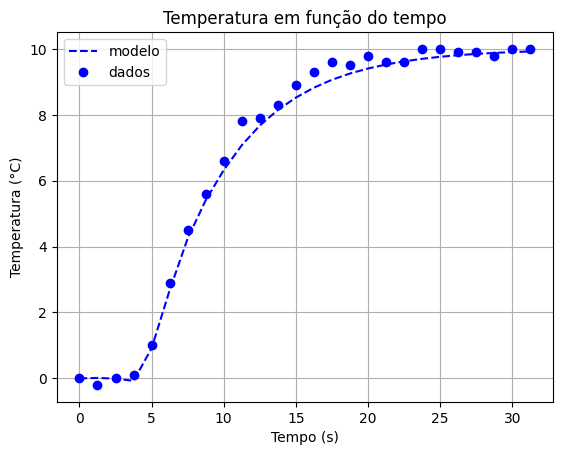

In [174]:
from types import GetSetDescriptorType
'''

BLOCO PARA RESOLUÇÃO DO PROBLEMA PROPOSTO
------------------------------------------------

DE ACORDO COM OS VALORES ENCONTRADOS NO BLOCO ANTERIOR,
É NECESSÁRIO IMPLANTAR O CONTROLE NO SISTEMA.


'''

#Definição do meu delta u

K = (T[-1] - T[0])/1

#Impressão do delta

print(f"O valor do meu delta u, considerando o degrau unitário, é: {K}")

#Definição do modelo

Gdt = ct.tf(*ct.pade(theta,5,3))
G = ct.tf(K,[tau,1])*Gdt

#Simulação dos dado

t,y = ct.step_response(G,T = t)

#Plotagem do gráfico

plt.plot(t, y, '--b', label= 'modelo')
plt.plot(t,T, 'ob',label = 'dados')
plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')
plt.grid()

###EXERCÍCIO PROPOSTO


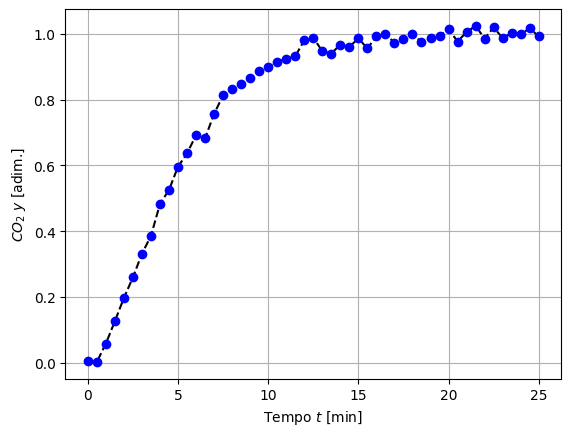

In [175]:
'''

BLOCO PARA IMPORTAÇÃO DOS DADOS EXPERIMENTAIS E
PLOTAGEM DOS GRÁFICOS

UTILIZANDO O Método de Sundaresan e Krishnaswamy

'''

#Definição dos dados de tempo e concentração, propostas no exercício

# Dados experimentais
t_2 = t = np.arange(0,25.5,0.5) #Intervalo de 0 a 25, caminhando de 0.5 segundos
y_CO2 = np.array(
      [0.00309765, 0.00179671, 0.05736463, 0.1259297 , 0.1965255 ,
       0.25928347, 0.33100036, 0.38557044, 0.48261651, 0.52532396,
       0.59605249, 0.63664968, 0.692138  , 0.682736  , 0.75676213,
       0.81374694, 0.8329348 , 0.84901645, 0.86510134, 0.88727795,
       0.89927448, 0.91638715, 0.92440394, 0.93261136, 0.9807045 ,
       0.98915155, 0.9478411 , 0.94059148, 0.96817854, 0.96085958,
       0.98704477, 0.95626661, 0.99332458, 1.00163399, 0.9728743 ,
       0.98581019, 1.00116753, 0.97514747, 0.98721072, 0.99374204,
       1.0151221 , 0.97736421, 1.00618801, 1.02481627, 0.98613209,
       1.02047745, 0.98770272, 1.00294645, 0.99945405, 1.01756078,
       0.99274144])

# Plotagem3 dos dados
plt.plot(t_2, y_CO2, marker='o', markerfacecolor='blue', markeredgecolor='blue',
         markeredgewidth=1, linestyle='--', color='black')
plt.xlabel("Tempo $t$ [min]")
plt.ylabel(r"$CO_2$ $y$ [adim.]")
plt.grid()


In [176]:
'''
BLOCO PARA RESOLUÇÃO DO PROBLEMA

-------------------------------------------

FOI FORNECIDO O t1 e t2 PARA SER ESTIPULADO NO GRÁFICO GERADO
NO BLOCO ANTERIOR. TORNANDO-SE POSSÍVEL CHUTAR VALORES PARA t1
E t2 PARA ESTIPULAR PARAMÊTROS DO SISTEMA.

'''

#Chute para t1 e t2

t1_2 = 3.15
t2_2 = 10.5

#Estipular os paramêtros theta e tau a partir dos valores de t1 e t2 que foram assumidos

theta_2 = 1.3*(t1_2) - 0.29*(t2_2)
tau_2 = 0.67*(t2_2 - t1_2)

#Impressão dos resultados encontrados dos paramêtros

print(theta_2)
print(tau_2)





1.0499999999999998
4.9245


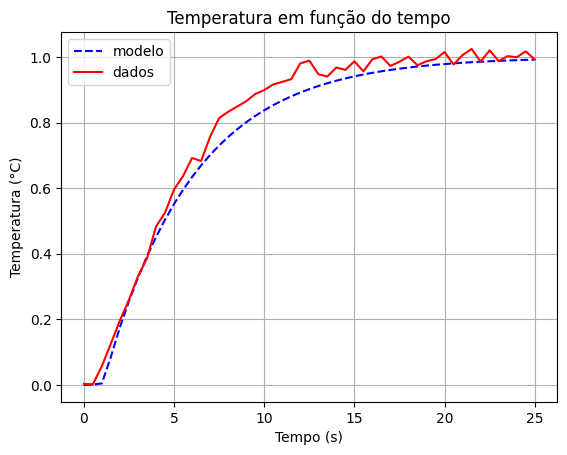

In [177]:
'''

BLOCO PARA RESOLUÇÃO DO PROBLEMA PROPOSTO
------------------------------------------------

DE ACORDO COM OS VALORES ENCONTRADOS NO BLOCO ANTERIOR,
É NECESSÁRIO IMPLANTAR O CONTROLE NO SISTEMA.


'''

#Definição do meu delta u

K_2 = 1
'''
#Impressão do delta

print(f"O valor do meu delta u, considerando o degrau unitário, é: {K}")
'''

#Definição do modelo

Gdt_2 = ct.tf(*ct.pade(theta_2,5,3))
G_2 = ct.tf(K_2,[tau_2,1])*Gdt_2

#Simulação dos dado

t_2,y = ct.step_response(G_2, T = t_2) #Esse T é do método, ele exige que seja T mas não necessariamente que seja a minha variavel

#Plotagem do gráfico

plt.plot(t_2, y, '--b', label= 'modelo')
plt.plot(t_2,y_CO2, 'red',label = 'dados')
plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura em função do tempo')
plt.grid()